In [101]:
import plotly.express as px
import pandas as pd
tot_losses = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/prova_test_LOSSES.csv')

fig_losses = px.line(tot_losses,x = 'epoch',y='loss',color = 'set',facet_col='model',width = 2600)
#fig_losses.update_traces(mode="markers+lines", hovertemplate=None)
#fig_losses.update_layout(hovermode="x unified")
fig_losses.update_layout(title = {'text':f'Losses', 'x':0.5},
                  xaxis_title={'text':'Epochs'},
                  yaxis_title={'text':'Value'},
                    )
    
fig_losses

In [102]:
import plotly.express as px
import pandas as pd
import numpy as np
tot_losses = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/prova_test_LOSSES.csv')
for c in tot_losses.model.unique():
    fig_losses = px.line(tot_losses[tot_losses.model==c],x = 'epoch',y='loss',color = 'set')
    fig_losses.update_layout(title = {'text':f'Losses '+c, 'x':0.5},
                  xaxis_title={'text':'Epochs'},
                  yaxis_title={'text':'Value'},

                    )
    fig_losses.show()

In [86]:
import plotly.express as px
import pandas as pd
import numpy as np

pred_temp = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/ttm_load_preds_0.7.csv')
pred_temp = pred_temp.loc[pred_temp['DATASET'] == 'TEST'].drop(columns=['DATASET'])
pred_temp.loc[pred_temp['ElectricWConsumed_pred'] < 0, 'ElectricWConsumed_pred'] = 0
pred_temp['model'] = 'ttm'

tot_pred = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/prova_test_tot_predictions.csv', index_col=0)
tot_pred.sort_values(by='time',inplace=True)
tot_pred.loc[tot_pred['ElectricWConsumed_pred'] < 0, 'ElectricWConsumed_pred'] = 0
#tot_pred.y_median[tot_pred.model=='d3vae_weather_1'] = tot_pred.y_pred[tot_pred.model=='d3vae_weather_1']
#tot_pred.y_median[tot_pred.model=='persistent_weather_1'] = tot_pred.y_pred[tot_pred.model=='persistent_weather_1']
tot_pred = pd.concat([tot_pred, pred_temp])
tot_pred.head()

,lag,time,ElectricWConsumed,ElectricWConsumed_pred,t,t_pred,prediction_time,model
0,1,2024-09-25 09:00:00,154563.61,56612.510,7.771528,9.427001,2024-09-25 08:00:00,itransformer_incube_1
12672,1,2024-09-25 09:00:00,154563.61,98432.945,8.970814,9.664818,2024-09-25 08:00:00,ttm_incube_1
13200,2,2024-09-25 10:00:00,162301.83,132363.250,11.680926,9.465417,2024-09-25 08:00:00,ttm_incube_1
528,2,2024-09-25 10:00:00,162301.83,83826.984,10.536652,9.408094,2024-09-25 08:00:00,itransformer_incube_1
1,1,2024-09-25 10:00:00,162301.83,105440.000,10.536652,9.418708,2024-09-25 09:00:00,itransformer_incube_1


In [103]:
import plotly.express as px
import pandas as pd
import numpy as np

pred_temp = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/ttm_load_preds_0.7.csv')
pred_temp = pred_temp.loc[pred_temp['DATASET'] == 'TEST'].drop(columns=['DATASET'])
pred_temp.loc[pred_temp['ElectricWConsumed_pred'] < 0, 'ElectricWConsumed_pred'] = 0
pred_temp['model'] = 'ttm'

tot_pred = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/prova_test_tot_predictions.csv', index_col=0)
tot_pred.sort_values(by='time',inplace=True)
tot_pred.loc[tot_pred['ElectricWConsumed_median'] < 0, 'ElectricWConsumed_median'] = 0
tot_pred.loc[tot_pred['ElectricWConsumed_low'] < 0, 'ElectricWConsumed_low'] = 0
tot_pred = tot_pred.rename(columns={'ElectricWConsumed_median': 'ElectricWConsumed_pred'})
#tot_pred.y_median[tot_pred.model=='d3vae_weather_1'] = tot_pred.y_pred[tot_pred.model=='d3vae_weather_1']
#tot_pred.y_median[tot_pred.model=='persistent_weather_1'] = tot_pred.y_pred[tot_pred.model=='persistent_weather_1']
tot_pred = pd.concat([tot_pred, pred_temp])
tot_pred.head()

,lag,time,ElectricWConsumed,ElectricWConsumed_low,ElectricWConsumed_pred,ElectricWConsumed_high,prediction_time,model
0,1,2024-09-25 09:00:00,154563.61,30789.540,77198.100,129558.516,2024-09-25 08:00:00,itransformer_incube_1
12672,1,2024-09-25 09:00:00,154563.61,27088.125,118464.234,156041.970,2024-09-25 08:00:00,ttm_incube_1
13200,2,2024-09-25 10:00:00,162301.83,47136.266,139265.340,174050.420,2024-09-25 08:00:00,ttm_incube_1
528,2,2024-09-25 10:00:00,162301.83,29898.576,110731.164,173741.390,2024-09-25 08:00:00,itransformer_incube_1
1,1,2024-09-25 10:00:00,162301.83,70864.840,147896.310,193159.120,2024-09-25 09:00:00,itransformer_incube_1


In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

#pred_temp = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/ttm_load_preds_0.7.csv')
pred_temp = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/ttm_interval.csv')
pred_temp = pred_temp.loc[pred_temp['DATASET'] == 'TEST'].drop(columns=['DATASET'])
pred_temp.loc[pred_temp['ElectricWConsumed_median'] < 0, 'ElectricWConsumed_median'] = 0
pred_temp.loc[pred_temp['ElectricWConsumed_low'] < 0, 'ElectricWConsumed_low'] = 0
pred_temp = pred_temp.rename(columns={'ElectricWConsumed_median': 'ElectricWConsumed_pred'})
pred_temp['model'] = 'ttm'

tot_pred = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/prova_test_tot_predictions.csv', index_col=0)
tot_pred.sort_values(by='time',inplace=True)
tot_pred.loc[tot_pred['ElectricWConsumed_pred'] < 0, 'ElectricWConsumed_pred'] = 0
#tot_pred.y_median[tot_pred.model=='d3vae_weather_1'] = tot_pred.y_pred[tot_pred.model=='d3vae_weather_1']
#tot_pred.y_median[tot_pred.model=='persistent_weather_1'] = tot_pred.y_pred[tot_pred.model=='persistent_weather_1']
tot_pred = pd.concat([tot_pred, pred_temp])
tot_pred.head()

In [98]:
import plotly.express as px
import pandas as pd
import numpy as np

tot_pred = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/prova_test_tot_predictions.csv', index_col=0)
tot_pred.sort_values(by='time',inplace=True)
tot_pred = tot_pred.rename(columns={'t_median': 't_pred'})
#tot_pred.loc[tot_pred['t_pred'] < 0, 't_pred'] = 0
#tot_pred.loc[tot_pred['t_low'] < 0, 't_low'] = 0
tot_pred.head()

,lag,time,ElectricWConsumed,ElectricWConsumed_pred,t,t_pred,prediction_time,model
0,1,2024-09-25 09:00:00,154563.61,56612.510,7.771528,9.427001,2024-09-25 08:00:00,itransformer_incube_1
12672,1,2024-09-25 09:00:00,154563.61,98432.945,8.970814,9.664818,2024-09-25 08:00:00,ttm_incube_1
13200,2,2024-09-25 10:00:00,162301.83,132363.250,11.680926,9.465417,2024-09-25 08:00:00,ttm_incube_1
528,2,2024-09-25 10:00:00,162301.83,83826.984,10.536652,9.408094,2024-09-25 08:00:00,itransformer_incube_1
1,1,2024-09-25 10:00:00,162301.83,105440.000,10.536652,9.418708,2024-09-25 09:00:00,itransformer_incube_1


In [34]:
import plotly.express as px
import pandas as pd
import numpy as np

tot_pred = pd.read_csv('/home/davide/Documents/WORKSPACE/ExpTS/incube_electricity/csv/ttm_interval.csv')
tot_pred = tot_pred.loc[tot_pred['DATASET'] == 'TEST'].drop(columns=['DATASET'])
tot_pred.loc[tot_pred['t_median'] < 0, 't_median'] = 0
tot_pred.loc[tot_pred['t_low'] < 0, 't_low'] = 0
tot_pred = tot_pred.rename(columns={'t_median': 't_pred'})
tot_pred['model'] = 'ttm'

tot_pred.head()

,lag,time,ElectricWConsumed,ElectricWConsumed_low,ElectricWConsumed_median,ElectricWConsumed_high,t,t_low,t_pred,t_high,prediction_time,model
56160,1,2024-09-25 09:00:00,154563.610,33976.527,85677.95,116511.19,10.171840,8.384365,9.529136,11.526044,2024-09-25 08:00:00,ttm
56161,1,2024-09-25 10:00:00,162301.830,73453.770,140821.48,161461.20,10.893992,8.398591,9.523949,11.523040,2024-09-25 09:00:00,ttm
56162,1,2024-09-25 11:00:00,149320.230,70531.320,137241.84,159012.31,10.164151,9.854704,11.060665,12.879162,2024-09-25 10:00:00,ttm
56163,1,2024-09-25 12:00:00,147635.600,62229.055,129750.51,153563.97,12.033862,10.722906,12.197727,13.747458,2024-09-25 11:00:00,ttm
56164,1,2024-09-25 13:00:00,42897.035,56777.260,131706.94,156489.36,15.597228,13.076646,14.694025,16.139940,2024-09-25 12:00:00,ttm


In [104]:
lag=17
fig = px.line(tot_pred[(tot_pred.lag==lag)], x='time', y='ElectricWConsumed_pred', color='model',width=2200,height=800)
fig.add_scatter(x = tot_pred[(tot_pred.lag==lag) & (tot_pred.model==tot_pred.model.unique()[0])].time, y=tot_pred[(tot_pred.lag==lag) & (tot_pred.model==tot_pred.model.unique()[0])].ElectricWConsumed)

In [105]:
lag=1
fig = px.line(tot_pred[(tot_pred.lag==lag)], x='time', y='ElectricWConsumed_pred', color='model',width=2200,height=800)
fig.add_scatter(x = tot_pred[(tot_pred.lag==lag) & (tot_pred.model==tot_pred.model.unique()[0])].time, y=tot_pred[(tot_pred.lag==lag) & (tot_pred.model==tot_pred.model.unique()[0])].ElectricWConsumed)

In [99]:
lag=1
fig = px.line(tot_pred[(tot_pred.lag==lag)], x='time', y='t_pred', color='model',width=2200,height=800)
fig.add_scatter(x = tot_pred[(tot_pred.lag==lag) & (tot_pred.model==tot_pred.model.unique()[0])].time, y=tot_pred[(tot_pred.lag==lag) & (tot_pred.model==tot_pred.model.unique()[0])].t)

In [106]:
import numpy as np
error = tot_pred.groupby(['lag','model']).apply(lambda x: np.nanmean(np.abs(x.ElectricWConsumed-x.ElectricWConsumed_pred))).reset_index().rename(columns={0:'error'}) 
import numpy as np
fig = px.line(error, x='lag', y='error', color='model',height=800)
fig.show() #150--400

/tmp/ipykernel_7724/3718085181.py:2: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [107]:
px.bar(error.groupby('model').error.mean().reset_index().sort_values(by='error'),y='model',x='error',height=1000)

In [55]:
error = tot_pred.groupby(['lag','model']).apply(lambda x: 100*np.nanmean(np.abs(x.ElectricWConsumed-x.ElectricWConsumed_pred)/x.ElectricWConsumed_pred)).reset_index().rename(columns={0:'error'}) 
fig = px.line(error, x='lag', y='error', color='model',height=800)
fig.show() #150--400

/tmp/ipykernel_7724/3629543584.py:1: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [108]:
from sklearn.metrics import r2_score
df_plot = tot_pred.groupby(['model', 'lag']).apply(lambda x: r2_score(x['ElectricWConsumed'], x['ElectricWConsumed_pred']), include_groups=False).reset_index(name='R2')
df_plot['SIZE_DATASET'] = 0.7
df_test = df_plot.loc[(df_plot['lag'].isin([1,12,23]))]

fig = px.bar(df_test, 
             x="SIZE_DATASET", 
             y="R2", 
             color="model", 
             facet_col="lag", 
             facet_col_wrap=3,
             barmode="group",
             height=600,

             facet_row_spacing=0.005,
             #facet_col_spacing=0.1
             )

fig.update_layout(
        title={
            'text': 'Z-WAVE_7E',
            'x': 0.5,
            'xanchor': 'center',
            'font': {
                'size': 24,
                'color': 'darkblue'
            }
        },
        legend=dict(
            font=dict(
                size=16  # Imposta qui la dimensione che preferisci
                ))
    )
fig.update_annotations(font=dict(size=18))
fig.update_xaxes(tickfont=dict(size=18))
fig.update_yaxes(range=[-0.5, 1])
for axis in fig.layout:
    if axis.startswith("xaxis") or axis.startswith("yaxis"):
        fig.layout[axis].title.font = dict(size=18)


fig.show()

In [100]:
from sklearn.metrics import r2_score
df_plot = tot_pred.groupby(['model', 'lag']).apply(lambda x: r2_score(x['t'], x['t_pred']), include_groups=False).reset_index(name='R2')
df_plot['SIZE_DATASET'] = 0.7
df_test = df_plot.loc[(df_plot['lag'].isin([1,12,23]))]

fig = px.bar(df_test, 
             x="SIZE_DATASET", 
             y="R2", 
             color="model", 
             facet_col="lag", 
             facet_col_wrap=3,
             barmode="group",
             height=600,

             facet_row_spacing=0.005,
             #facet_col_spacing=0.1
             )

fig.update_layout(
        title={
            'text': 'Z-WAVE_7E',
            'x': 0.5,
            'xanchor': 'center',
            'font': {
                'size': 24,
                'color': 'darkblue'
            }
        },
        legend=dict(
            font=dict(
                size=16  # Imposta qui la dimensione che preferisci
                ))
    )
fig.update_annotations(font=dict(size=18))
fig.update_xaxes(tickfont=dict(size=18))
fig.update_yaxes(range=[-0.5, 1])
for axis in fig.layout:
    if axis.startswith("xaxis") or axis.startswith("yaxis"):
        fig.layout[axis].title.font = dict(size=18)


fig.show()

In [109]:
date  ='2024-09-27 00:00:00'
subset = tot_pred[(tot_pred.prediction_time==date)]
fig = px.line(subset, x='lag', y='ElectricWConsumed_pred', color='model',height=800)
fig.add_scatter(x = subset.lag[subset.model==subset.model.unique()[0]], y=subset.ElectricWConsumed[subset.model==subset.model.unique()[0]])

fig.show()

In [110]:
date  ='2024-09-27 00:00:00'
model = 'ttm_incube_1'
subset = tot_pred[(tot_pred.prediction_time==date) & (tot_pred.model==model)]
fig = px.line(subset, x='lag', y='ElectricWConsumed_pred', color='model',height=800)
fig.add_scatter(x = subset.lag, y=subset.ElectricWConsumed)
 # Area tra quantili (fill='tonexty' fa il "riempimento")
fig.add_scatter(
    x=subset.lag,
    y=subset.ElectricWConsumed_high,
    mode='lines',
    line=dict(width=0),
    name=f"upper q",
    showlegend=False
)
fig.add_scatter(
    x=subset.lag,
    y=subset.ElectricWConsumed_low,
    mode='lines',
    fill='tonexty',  # fill tra questo e il precedente
    line=dict(width=0),
    fillcolor='rgba(0,100,80,0.2)',  # trasparente
    name=f"conf interval"
)
fig.show()

In [ ]:
date  ='2024-09-27 00:00:00'
model = 'ttm_incube_1'
subset = tot_pred[(tot_pred.prediction_time==date) & (subset.model==model)]
fig = px.line(subset, x='lag', y='t_pred', color='model',height=800)
fig.add_scatter(x = subset.lag, y=subset.t)
 # Area tra quantili (fill='tonexty' fa il "riempimento")
fig.add_scatter(
    x=subset.lag,
    y=subset.t_high,
    mode='lines',
    line=dict(width=0),
    name=f"upper q",
    showlegend=False
)
fig.add_scatter(
    x=subset.lag,
    y=subset.t_low,
    mode='lines',
    fill='tonexty',  # fill tra questo e il precedente
    line=dict(width=0),
    fillcolor='rgba(0,100,80,0.2)',  # trasparente
    name=f"conf interval"
)
fig.show()

In [26]:
def create_serie(start_date, end_date, freq='1h'):
    # Crea indice orario
    time_index = pd.date_range(start=start_date, end=end_date, freq=freq)

    # Stagionalità giornaliera: una sinusoide su 24 ore
    hours = np.arange(len(time_index))
    daily_period = 24
    amplitude = 10
    baseline = 20
    noise = np.random.normal(0, 1, len(time_index))  # Rumore gaussiano

    # Funzione sinusoidale giornaliera con rumore
    values = baseline + amplitude * np.sin(2 * np.pi * (hours % daily_period) / daily_period) + noise

    # Serie temporale
    serie_stagionale = pd.Series(values, index=time_index)
    return serie_stagionale
    #return values

In [32]:
start_date = '2024-09-01'
end_date = '2024-09-04'
serie = create_serie(start_date, end_date, freq='1h')
fig = px.line(serie,height=800)
fig.show()

## Other

In [5]:
tot_pred[tot_pred.model.str.contains('patc')].model.unique()

array([], dtype=object)

In [5]:
tot_pred.y_pred[np.isnan(tot_pred.y_pred)] = tot_pred.y_median[np.isnan(tot_pred.y_pred)]

/tmp/ipykernel_22944/1349017750.py:1: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/tmp/ipykernel_22944/1349017750.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the doc

In [ ]:
lag=17
fig = px.line(tot_pred[(tot_pred.lag==lag)], x='time', y='y_pred', color='model',width=2200,height=800)
fig.add_scatter(x = tot_pred[(tot_pred.lag==lag) & (tot_pred.model==tot_pred.model.unique()[0])].time, y=tot_pred[(tot_pred.lag==lag) & (tot_pred.model==tot_pred.model.unique()[0])].y)


In [7]:
px.bar(error.groupby('model').error.mean().reset_index().sort_values(by='error'),y='model',x='error',height=1000)

NameError: name 'error' is not defined

In [8]:
import numpy as np
error = tot_pred.groupby(['lag','model']).apply(lambda x: np.nanmean(np.abs(x.y-x.y_pred))).reset_index().rename(columns={0:'error'}) 
import numpy as np
fig = px.line(error, x='lag', y='error', color='model',height=800)
fig.show() #150--400

AttributeError: 'DataFrame' object has no attribute 'y'

/home/agobbi/miniconda3/envs/tt/lib/python3.12/site-packages/plotly/express/_core.py:1979: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



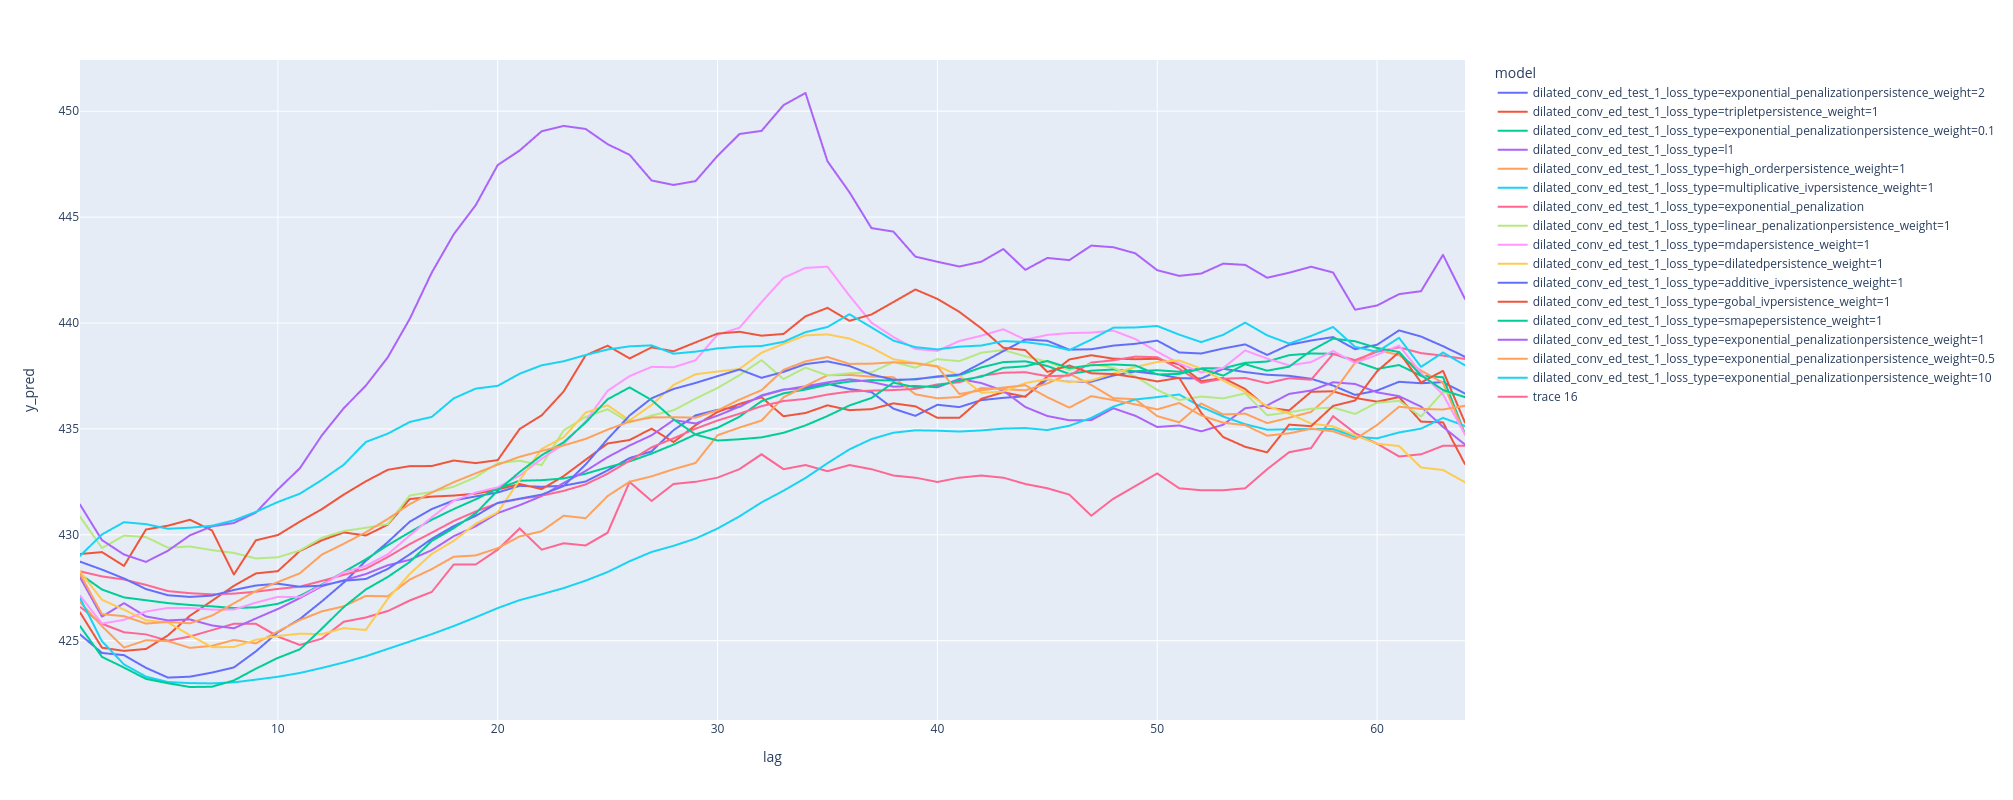

In [10]:
#27-11-2020
date  ='2020-12-19 13:20:00'
subset = tot_pred[(tot_pred.prediction_time==date)&(tot_pred.model.str.contains('dilated'))]
fig = px.line(subset, x='lag', y='y_pred', color='model',height=800)
fig.add_scatter(x = subset.lag[subset.model==subset.model.unique()[0]], y=subset.y[subset.model==subset.model.unique()[0]])

fig.show()

In [18]:
agg = tot_pred_new.groupby(['prediction_time','model']).apply(compute_fun).reset_index().dropna()


In [19]:
pd.set_option('display.max_colwidth', None)

agg.groupby('model')[['error','error_p','error_tot']].mean().reset_index().sort_values(by='error_p')

,model,error,error_p,error_tot
6,persistent,1166.587392,0.000000,2333.174783
1,diffusion_test_1_loss_type=mse,1165.423695,239.860320,1186.672738
0,diffusion_test_1_loss_type=exponential_penalization,1164.679636,243.186244,1167.709127
5,patchtst_weather_1_loss_type=mse,8.925319,1167.584922,8.925319
4,patchtst_weather_1_loss_type=exponential_penalization,8.937888,1167.676675,8.937888
3,dilated_conv_ed_test_1_loss_type=mse,6.415852,1169.690167,6.415852
7,tft_weather_1_loss_type=exponential_penalization,9.345912,1169.808374,9.345912
8,tft_weather_1_loss_type=mse,10.086456,1171.115744,10.086456
2,dilated_conv_ed_test_1_loss_type=exponential_penalization,7.164516,1171.221872,7.164516


In [9]:
#27-11-2020
date  ='2020-12-19 13:20:00'
subset = tot_pred_new[(tot_pred_new.prediction_time==date)]
fig = px.line(subset, x='lag', y='y_pred', color='model',height=800)
fig.add_scatter(x = subset.lag[subset.model==subset.model.unique()[0]], y=subset.y[subset.model==subset.model.unique()[0]])

fig.show()

NameError: name 'tot_pred_new' is not defined

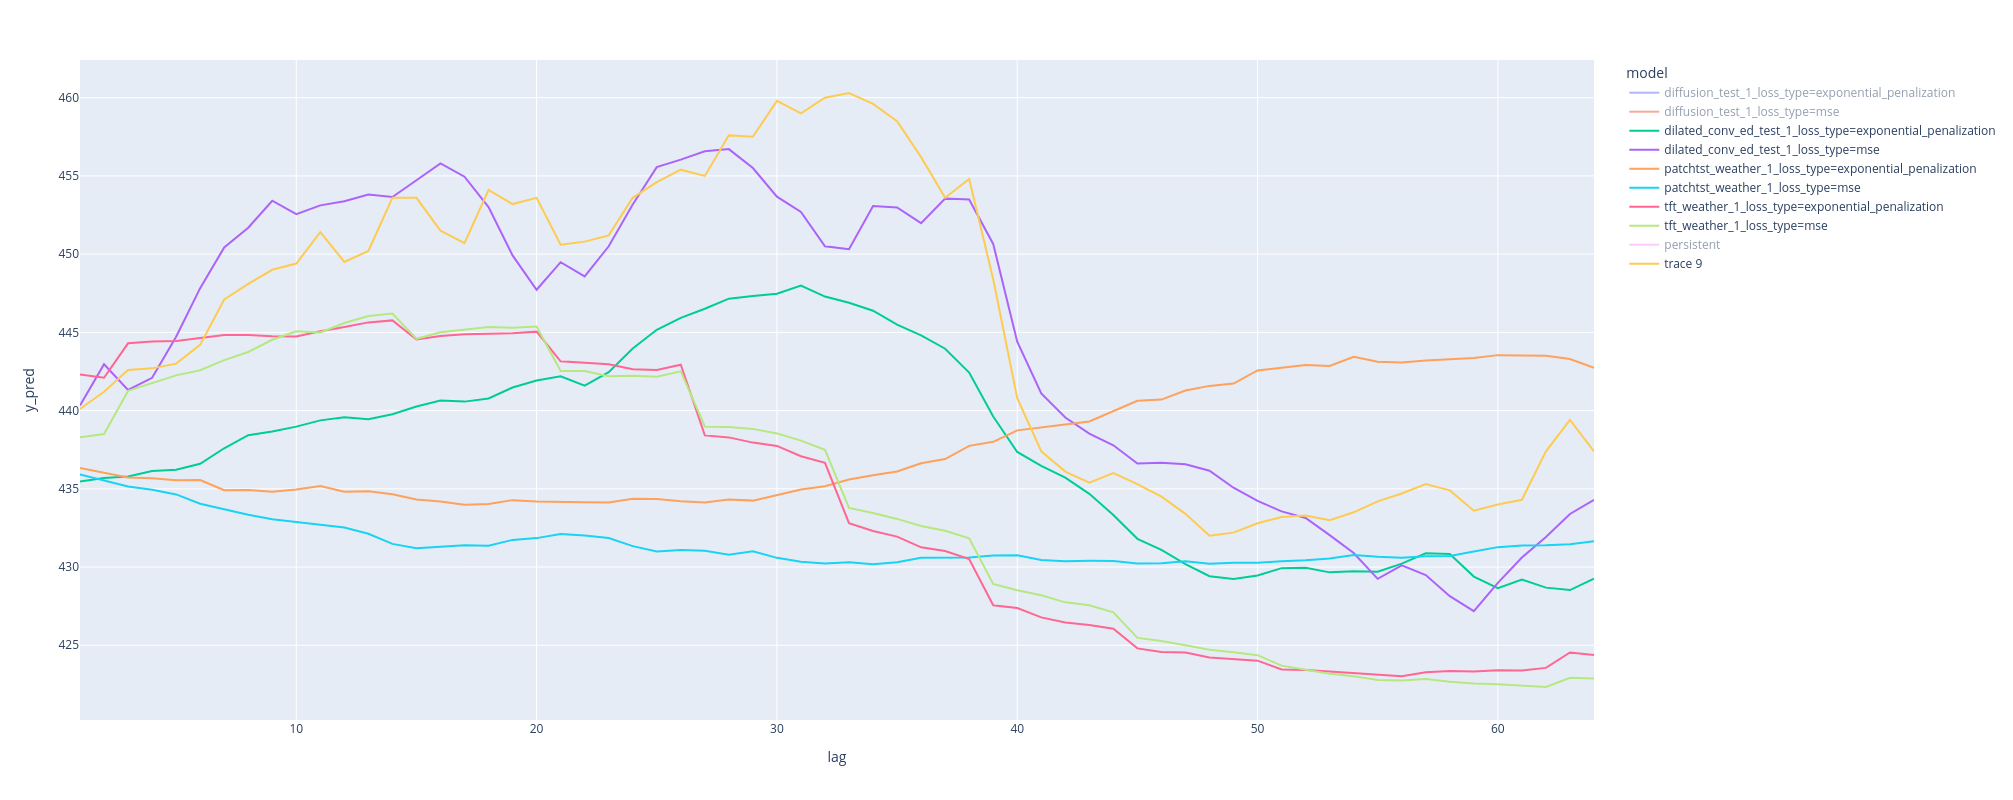

In [23]:
date  ='2020-12-08 05:30:00'
subset = tot_pred_new[(tot_pred_new.prediction_time==date)]
fig = px.line(subset, x='lag', y='y_pred', color='model',height=800)
fig.add_scatter(x = subset.lag[subset.model==subset.model.unique()[0]], y=subset.y[subset.model==subset.model.unique()[0]])

fig.show()

In [21]:
import plotly.express as px
import pandas as pd
import numpy as np
tot_pred = pd.read_csv('/home/agobbi/Projects/ExpTS/weather_paper/csv/prova_test_tot_predictions.csv')
tot_pred.sort_values(by='time',inplace=True)



FileNotFoundError: [Errno 2] No such file or directory: '/home/agobbi/Projects/ExpTS/weather_paper/csv/prova_test_tot_predictions.csv'

In [22]:
error = tot_pred.groupby(['lag','model']).apply(lambda x: 100*np.nanmean(np.abs(x.y-x.y_pred)/x.y)).reset_index().rename(columns={0:'error'}) 
fig = px.line(error, x='lag', y='error', color='model',height=600,width=1000)
fig.update_layout(legend=dict(x=0.65,y=.1),font=dict(size=16)) 
fig.write_image('error.pdf')

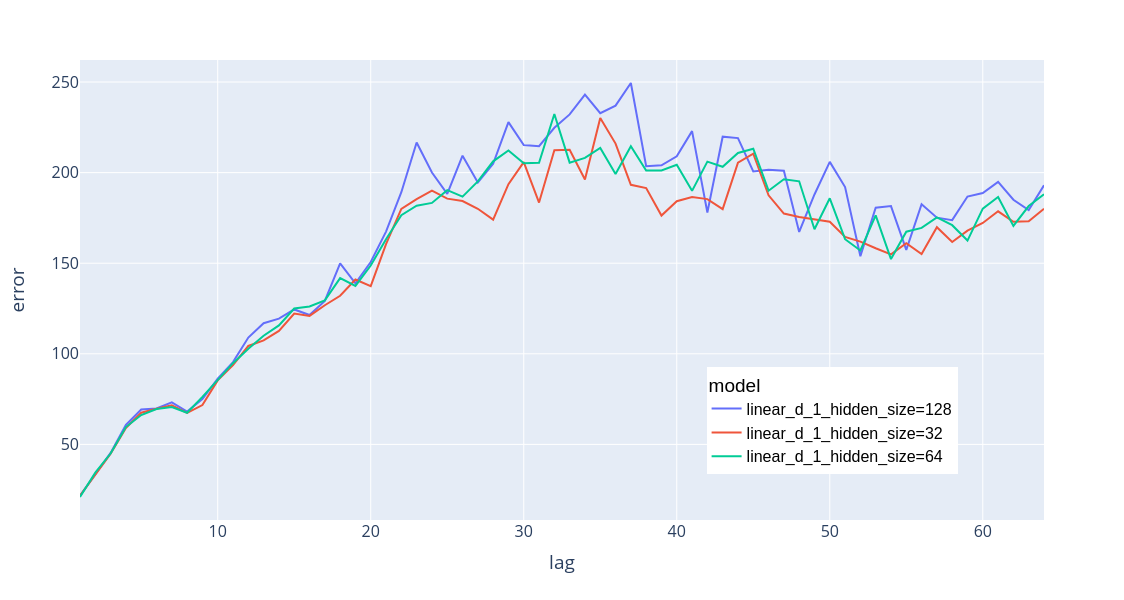